# Bibliotecas

In [63]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, precision_recall_curve, auc

import optuna
import mlflow
import mlflow.sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score


# Prepara base de modelagem

In [64]:
df = pd.read_csv("C:\\Users\\Usuario\\Downloads\\insuranceFraud_1.csv")

In [65]:
df2 = df.copy()
df2['authorities_contacted'] = df2['authorities_contacted'].fillna('Other')

In [66]:
df3 = pd.get_dummies(df2, columns=['policy_state','policy_csl','insured_sex','insured_education_level','insured_occupation','insured_hobbies','insured_relationship','incident_type','collision_type','incident_severity'
,'authorities_contacted','incident_state','property_damage','police_report_available','auto_make'], drop_first=True)

In [67]:
#algumas variáveis não fazem sentido para modelagem:
df3 = df3.drop(['policy_bind_date','incident_date'],axis=1)

#algumas variáveis categórias tem alta dimensionalidade, e podem causar problemas na modelagem, uma vez que se amostra uma parte das variáveis a cada iteração,
#e muitas flags podem causar viés na aleatoridade
df3 = df3.drop(['incident_city','incident_location','insured_zip','auto_model'],axis=1)

In [68]:
#criar variável resposta dummy
df3['target'] = (df3['fraud_reported'] == 'Y').astype(int)
df3 = df3.drop('fraud_reported',axis=1)

<Axes: >

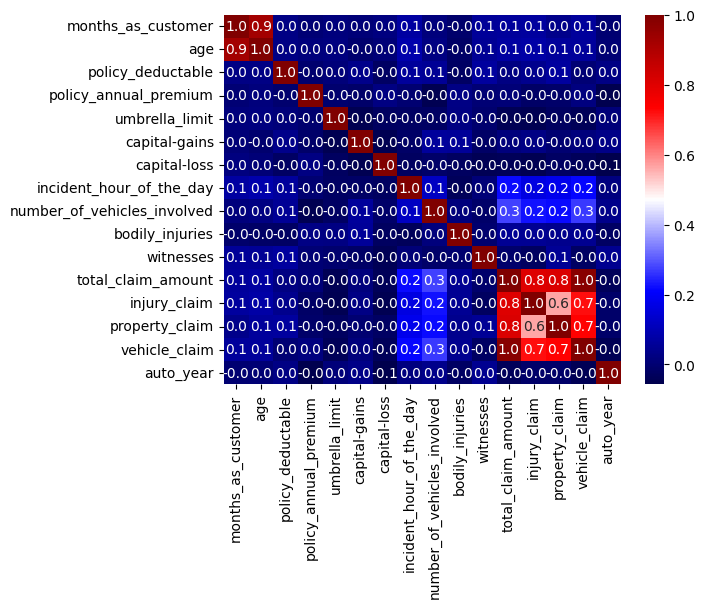

In [69]:
#somente entre features não dummy
non_dummies = df3.select_dtypes(exclude=['bool'])
sns.heatmap(non_dummies.drop(['policy_number','target'],axis=1).corr(), cmap='seismic', annot=True, fmt=".1f")

In [70]:
X = df3.drop(['policy_number','target','total_claim_amount','months_as_customer','vehicle_claim'],axis=1)
y = df3['target']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=22)

# MLFlow

In [ ]:
import mlflow
import mlflow.sklearn


# ===== MLflow setup =====

# --- Pasta para salvar os experimento - precisa ser neste formato "file"
mlflow.set_tracking_uri("file:///C:/Users/Usuario/Desktop/mlflow_runs2")

# --- Nome do experimento: cria (se não existir) e usa o mesmo experimento em todas as rodadas deste notebook
mlflow.set_experiment("gbm_optuna_ml")


# ===== Optuna =====
# --- Define função objetiva que será otimizada no optuna
def objective(trial):

    #hiperparâmetros do trial
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 20, 50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 20, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'random_state': 42
    }

    model = GradientBoostingClassifier(**params)

    #otimização por acurácia com cross validation com 10 folds
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1).mean()

    return cv_acc

#  --- Roda o estudo optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

# --- Roda o melhor modelo do estudo
best_params = study.best_params.copy()
best_model = GradientBoostingClassifier(**best_params).fit(X_train, y_train)

# --- Mostra as características do melhor modelo
print("Best params:", study.best_params)
print("Best CV accuracy:", study.best_value)
print("Train accuracy:", accuracy_score(y_train, best_model.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test,  best_model.predict(X_test)))


# ===== MLflow runs =====

# --- Registra um run com melhor modelo do estudo anterior -- cada alteração + rodada feita, vai gerar um run diferente

search_space_id = "gbm_space_v3" #nome do run - alterar a cada rodada

with mlflow.start_run(run_name=f"best_{search_space_id}") as run:
    
    mlflow.log_params(best_params) #registra os hiperparâmetros
    mlflow.log_metric("study_accuracy", study.best_value) #registra a acurácia no optuna
    mlflow.log_metric("train_accuracy", accuracy_score(y_train, best_model.predict(X_train))) #registra a acurácia na base de treino
    mlflow.log_metric("test_accuracy",  accuracy_score(y_test,  best_model.predict(X_test))) #registra a acurácia na base de teste
    mlflow.sklearn.log_model(best_model, artifact_path="model") #salva o modelo, e pode ser usado para escorar bases depois

    mlflow.log_dict({ 
        "search_space_id": search_space_id,
        "n_trials": len(study.trials),
        "best_trial": study.best_trial.number,
        "cv": {"n_splits": 10, "shuffle": True, "random_state": 42}
    }, "search_space_summary.json") #registra o que foi testado nesse run

    print("OK! Best salvo. Run ID:", run.info.run_id) #registra o número do run


[I 2025-10-04 15:15:08,439] A new study created in memory with name: no-name-6220fdfc-2193-416d-acec-90c08c00dd82
[I 2025-10-04 15:15:35,957] Trial 0 finished with value: 0.7871428571428571 and parameters: {'n_estimators': 31, 'learning_rate': 0.08520726819531067, 'max_depth': 4, 'min_samples_leaf': 21, 'subsample': 0.7364277606640202}. Best is trial 0 with value: 0.7871428571428571.
[I 2025-10-04 15:15:37,184] Trial 1 finished with value: 0.8099999999999999 and parameters: {'n_estimators': 33, 'learning_rate': 0.06808247646707315, 'max_depth': 5, 'min_samples_leaf': 22, 'subsample': 0.8750832379995145}. Best is trial 1 with value: 0.8099999999999999.
[I 2025-10-04 15:15:38,012] Trial 2 finished with value: 0.7685714285714285 and parameters: {'n_estimators': 34, 'learning_rate': 0.0898263875509035, 'max_depth': 4, 'min_samples_leaf': 22, 'subsample': 0.5006947464042499}. Best is trial 1 with value: 0.8099999999999999.
[I 2025-10-04 15:15:38,644] Trial 3 finished with value: 0.781428571

Best params: {'n_estimators': 33, 'learning_rate': 0.06808247646707315, 'max_depth': 5, 'min_samples_leaf': 22, 'subsample': 0.8750832379995145}
Best CV accuracy: 0.8099999999999999
Train accuracy: 0.9085714285714286
Test accuracy: 0.8066666666666666


2025/10/04 15:15:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/04 15:16:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


OK! Best salvo. Run ID: 1a06a9d8c4d6493d8b36bff697608f31


Para ver e comparar os experimentos e run, rodar no terminal:

mlflow ui --backend-store-uri "file:///C:/Users/Usuario/Desktop/mlflow_runs2" --port 5000

E abrir a url http://127.0.0.1:5000

Na "vida real" o modelo final é registrado em outro stage (stage/production). Na hora de usar chama direto desse registry.

# Escorar uma base usando um modelo salvo

In [ ]:
import mlflow.sklearn

# Run id do modelo final
run_id = "6c099ae2db3945ddaf439e3c7818f27e"
model_uri = f"runs:/{run_id}/model"

# Carrega o modelo salvo no MLflow
best_model = mlflow.sklearn.load_model(model_uri)

# Usa normalmente
y_pred = best_model.predict(X_test)
print(y_pred[:10])